# Figure1_3

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure1")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsM
from functions.utils import first_trial_accuracy
from functions.plotting import set_paper_theme

set_paper_theme()


## Data preparation: multitask training

In [3]:
task_list = [
    "animate_vs_inanimate",
    "natural_vs_artificial",
    "mammal_vs_reptile",
    "monkey_vs_mammal",
    "human_vs_monkey",
    "electronics_vs_tools",     
    ]
Colors = ["black","#8074B1","#5EA66B","#BF5155","#D88558","#897A63"]

## Panel H - Trial-based learning curves

In [4]:
# trials-based learning curve with mixed bins: 25-trial bins for the first 400 trials, then 200-trial bins up to 3000
# all main sessions (islearn=False, including early training), averaged across monkeys
binsize1, n_bins1 = 25, 16   # 0-400 trials
binsize2, n_bins2 = 200, 13  # 400-3000 trials; monkeys with fewer complete bins padded with NaN, averaged via nanmean

lr1, lr2 = [], []
for task in task_list:
    cm1, cm2 = [], []
    for monkey in ["Elsa","Judy","Olaf"]:
        trials,files = loadTrialsM(task,monkey,islearn=False,extend=True,verbose=False)
        res = [tr["result"]=="CORRECT" for tr in trials[:n_bins1*binsize1 + n_bins2*binsize2]]
        cm1.append([np.mean(res[i*binsize1:(i+1)*binsize1]) for i in range(n_bins1)])
        rem = res[n_bins1*binsize1:]
        cr2 = [np.mean(rem[i*binsize2:(i+1)*binsize2]) for i in range(len(rem)//binsize2)]
        cm2.append(cr2 + [np.nan]*(n_bins2-len(cr2)))
    lr1.append(np.mean(cm1,axis=0))
    lr2.append(np.nanmean(cm2,axis=0))

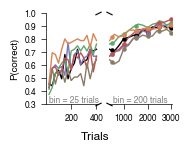

In [5]:
# broken-axis layout: left panel = 25-trial bins (0-400, with y-axis), right panel = 200-trial bins (400-3000, no y-axis)
fig,(ax1,ax2) = plt.subplots(1,2,gridspec_kw={"width_ratios":[1,1.2]})
fig.get_layout_engine().set(w_pad=1/72, wspace=0.005)  # narrow break between the two panels
fig.set(figheight=105/75,figwidth=130/75)

x1 = np.arange(1,n_bins1+1)*binsize1                      # 25..400
x2 = n_bins1*binsize1 + np.arange(0,n_bins2+1)*binsize2   # 400,600,...,3000
sx = np.arange(500,3001,500)                              # markers every 500 trials
for i in range(6):
    y2 = np.concatenate([lr1[i][-1:], lr2[i]])            # join the two segments at trial 400
    ax1.plot(x1,lr1[i],linewidth=1,color=Colors[i],zorder=1)
    ax2.plot(x2,y2,linewidth=1,color=Colors[i],zorder=1)
    ax2.scatter(sx,np.interp(sx,x2,y2),s=5,color=Colors[i],zorder=2)

ax1.set_xlim(0,410);   ax1.set_xticks([200,400])
ax2.set_xlim(390,3010);ax2.set_xticks([1000,2000,3000])
for a in (ax1,ax2): a.set_ylim(0.3,1)
ax1.set_yticks([0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
ax1.set_ylabel("P(correct)")
ax2.set_yticks([])
ax2.spines["left"].set_visible(False)

ax1.text(220,0.31,"bin = 25 trials",color="gray",fontsize=6,ha="center")
ax2.text(1700,0.31,"bin = 200 trials",color="gray",fontsize=6,ha="center")

# diagonal break marks at the axis gap
d = 0.5
kw = dict(marker=[(-1,-d),(1,d)],markersize=4.5,linestyle="none",color="black",clip_on=False,markeredgewidth=0.8)
ax1.plot([1],[0],transform=ax1.transAxes,**kw); ax1.plot([1],[1],transform=ax1.transAxes,**kw)
kw = dict(marker=[(1,-d),(-1,d)],markersize=4.5,linestyle="none",color="black",clip_on=False,markeredgewidth=0.8)
ax2.plot([0],[0],transform=ax2.transAxes,**kw); ax2.plot([0],[1],transform=ax2.transAxes,**kw)

fig.supxlabel("Trials")
plt.savefig(FIGURE_OUTPUT_DIR / f"multitask_learning_trials.pdf")
plt.show()

## Panel I — Generalization

In [6]:
task_list = [
    "animate_vs_inanimate_gen",
    "natural_vs_artificial_gen",
    "mammal_vs_reptile_gen",
    "monkey_vs_mammal_gen",
    "human_vs_monkey_gen",
    "electronics_vs_tools_gen",     
    ]
Colors = ["black","#8074B1","#5EA66B","#BF5155","#D88558","#897A63"]

In [7]:

p = []
se = []
for task in task_list:
    for monkey in ["Elsa","Judy","Olaf"]:
        trials,files = loadTrialsM(task,monkey,verbose=False)
        trials_gen = [tr for tr in trials if tr["trial_type"]=="gen" ]
        _p,_se,_ = first_trial_accuracy(trials_gen)
        p.append(_p)
        se.append(_se)


In [8]:
barwidth = 0.24
gap = 0.05
ticks = [1-barwidth,1,1+barwidth,2-barwidth,2,2+barwidth,
         3-barwidth,3,3+barwidth,4-barwidth,4,4+barwidth,
         5-barwidth,5,5+barwidth,6-barwidth,6,6+barwidth,
        ]
colors = [(Colors[0],1),(Colors[0],0.3),(Colors[0],0.7),
          (Colors[1],1),(Colors[1],0.3),(Colors[1],0.7),
          (Colors[2],1),(Colors[2],0.3),(Colors[2],0.7),
          (Colors[3],1),(Colors[3],0.3),(Colors[3],0.7),
          (Colors[4],1),(Colors[4],0.3),(Colors[4],0.7),
          (Colors[5],1),(Colors[5],0.3),(Colors[5],0.7)]

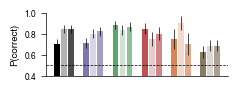

In [9]:
fig,ax = plt.subplots()
fig.set(figheight=60/75,figwidth=170/75)

ax.bar(ticks,p,width=barwidth-gap,color=colors,yerr=se,error_kw={"linewidth":0.5})

ax.axhline(0.5,color="black",linewidth=0.5,ls="--")


ax.set_xticks([])
ax.set_yticks([0.4,0.6,0.8,1])
ax.set_ylim([0.4,1])
ax.set_ylabel("P(correct)")
plt.savefig(FIGURE_OUTPUT_DIR / f"generalization_by_task.pdf")
plt.show()